<a href="https://colab.research.google.com/github/astro-prog/PRISM-Permission_and_Risk_Intelligent_System_Model/blob/main/PRISM_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRISM — Permission Risk Intelligence System for agentic Models
## Dataset Generation + Full ML Training Pipeline
**Run all cells top to bottom.**

In [ ]:
!pip install xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, warnings, os
from sklearn.model_selection     import train_test_split, cross_val_score
from sklearn.preprocessing       import LabelEncoder, StandardScaler
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier, IsolationForest
from sklearn.metrics             import (accuracy_score, f1_score, precision_score,
                                          recall_score, confusion_matrix,
                                          roc_auc_score, classification_report, roc_curve)
from xgboost import XGBClassifier
import shap
warnings.filterwarnings('ignore')
os.makedirs('prism_plots', exist_ok=True)
SEED = 42
print('✅ All imports successful')

✅ All imports successful


##  Step 1: Generate Dataset

In [ ]:
np.random.seed(42)
N = 5000

ACTION_TYPES = ['file_read','file_write','api_call','code_exec','db_read','db_write','web_search','email_send']
action_weights = [0.18, 0.10, 0.20, 0.10, 0.15, 0.08, 0.14, 0.05]
USER_ROLES = ['guest','user','developer','admin']
role_weights = [0.15, 0.40, 0.30, 0.15]

action_type       = np.random.choice(ACTION_TYPES, N, p=action_weights)
user_role         = np.random.choice(USER_ROLES,   N, p=role_weights)
data_sensitivity  = np.random.choice([0,1,2,3],    N, p=[0.35,0.30,0.20,0.15])
task_alignment    = np.round(np.random.beta(5, 2, N), 3)
request_frequency = np.random.randint(1, 60, N)
time_of_day       = np.random.randint(0, 24, N)
is_anomalous      = (request_frequency > 45).astype(int)

role_privilege = {'guest':0,'user':1,'developer':2,'admin':3}
privilege = np.array([role_privilege[r] for r in user_role])

action_base_risk = {'file_read':0.20,'file_write':0.40,'api_call':0.30,
                    'code_exec':0.65,'db_read':0.35,'db_write':0.70,
                    'web_search':0.15,'email_send':0.45}
base_risk = np.array([action_base_risk[a] for a in action_type])

risk_score = (
    base_risk * 0.30
    + (data_sensitivity / 3) * 0.25
    + (1 - task_alignment) * 0.20
    + (request_frequency / 60) * 0.10
    + is_anomalous * 0.20
    - (privilege / 3) * 0.10
)
risk_score = np.clip(risk_score, 0.0, 1.0)
noise_idx = np.random.choice(N, size=int(0.08*N), replace=False)
risk_score[noise_idx] += np.random.uniform(-0.15, 0.15, len(noise_idx))
risk_score = np.round(np.clip(risk_score, 0.0, 1.0), 4)

def assign_decision(r):
    if r < 0.35: return 'allow'
    elif r < 0.65: return 'escalate'
    else: return 'deny'

decision = np.array([assign_decision(r) for r in risk_score])

df = pd.DataFrame({
    'action_type': action_type, 'user_role': user_role,
    'data_sensitivity': data_sensitivity, 'task_alignment': task_alignment,
    'request_frequency': request_frequency, 'time_of_day': time_of_day,
    'is_anomalous': is_anomalous, 'privilege_level': privilege,
    'risk_score': risk_score, 'decision': decision
})
df.to_csv('prism_dataset.csv', index=False)
print(f'✅ Dataset generated: {df.shape}')
print(df['decision'].value_counts())
df.head()

✅ Dataset generated: (5000, 10)
decision
allow       3100
escalate    1795
deny         105
Name: count, dtype: int64


,action_type,user_role,data_sensitivity,task_alignment,request_frequency,time_of_day,is_anomalous,privilege_level,risk_score,decision
0,api_call,user,1,0.849,52,11,1,1,0.4569,escalate
1,email_send,user,0,0.783,25,19,0,1,0.1867,allow
2,db_write,admin,0,0.564,49,21,1,3,0.4789,escalate
3,db_read,user,1,0.682,36,8,0,1,0.2786,allow
4,file_read,admin,1,0.847,47,19,1,3,0.3523,escalate


## Step 2: EDA Plots

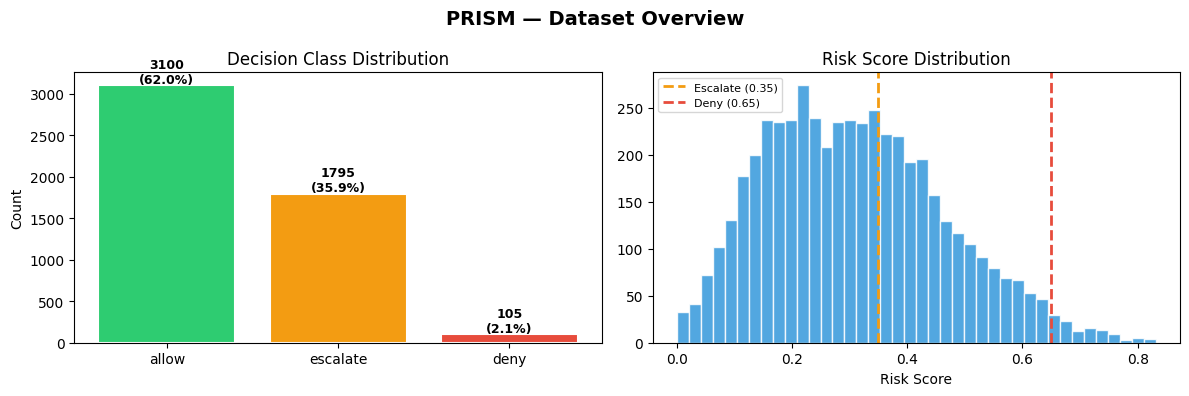

✅ Saved: 01_dataset_overview.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('PRISM — Dataset Overview', fontsize=14, fontweight='bold')
colors = {'allow':'#2ecc71','escalate':'#f39c12','deny':'#e74c3c'}
vc = df['decision'].value_counts()
axes[0].bar(vc.index, vc.values, color=[colors[d] for d in vc.index], edgecolor='white', linewidth=1.5)
axes[0].set_title('Decision Class Distribution'); axes[0].set_ylabel('Count')
for i,(k,v) in enumerate(vc.items()):
    axes[0].text(i, v+30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[1].hist(df['risk_score'], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(0.35, color='#f39c12', linestyle='--', linewidth=2, label='Escalate (0.35)')
axes[1].axvline(0.65, color='#e74c3c', linestyle='--', linewidth=2, label='Deny (0.65)')
axes[1].set_title('Risk Score Distribution'); axes[1].set_xlabel('Risk Score'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('prism_plots/01_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 01_dataset_overview.png')

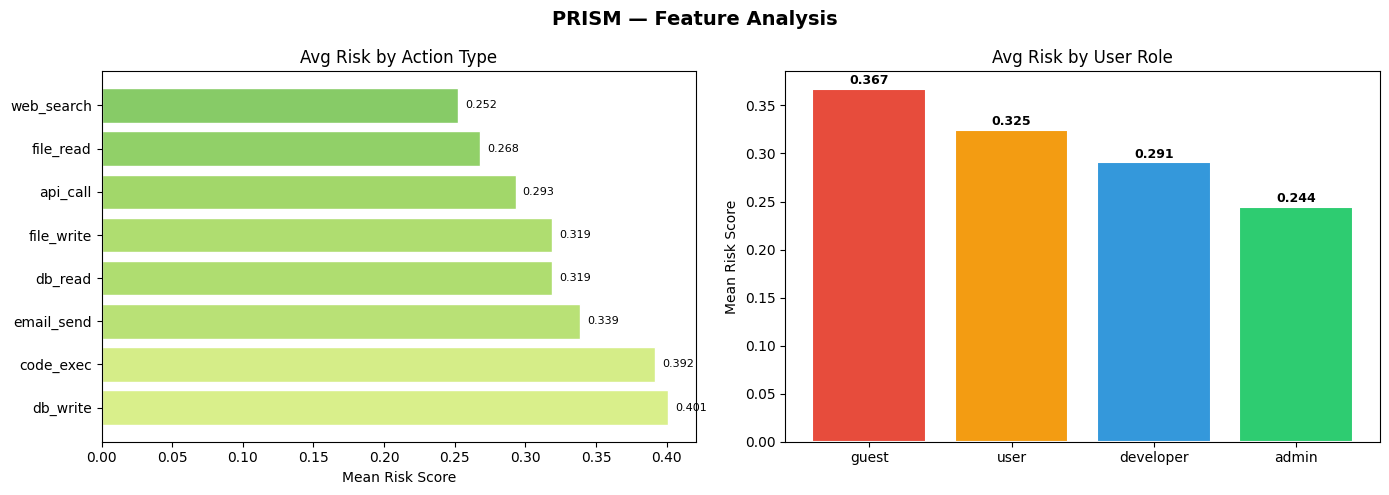

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PRISM — Feature Analysis', fontsize=14, fontweight='bold')
action_risk = df.groupby('action_type')['risk_score'].mean().sort_values(ascending=False)
axes[0].barh(action_risk.index, action_risk.values, color=plt.cm.RdYlGn_r(action_risk.values), edgecolor='white')
axes[0].set_title('Avg Risk by Action Type'); axes[0].set_xlabel('Mean Risk Score')
for i,v in enumerate(action_risk.values): axes[0].text(v+0.005, i, f'{v:.3f}', va='center', fontsize=8)
role_order = ['guest','user','developer','admin']
role_risk = df.groupby('user_role')['risk_score'].mean().reindex(role_order)
axes[1].bar(role_risk.index, role_risk.values, color=['#e74c3c','#f39c12','#3498db','#2ecc71'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Avg Risk by User Role'); axes[1].set_ylabel('Mean Risk Score')
for i,v in enumerate(role_risk.values): axes[1].text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('prism_plots/02_feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

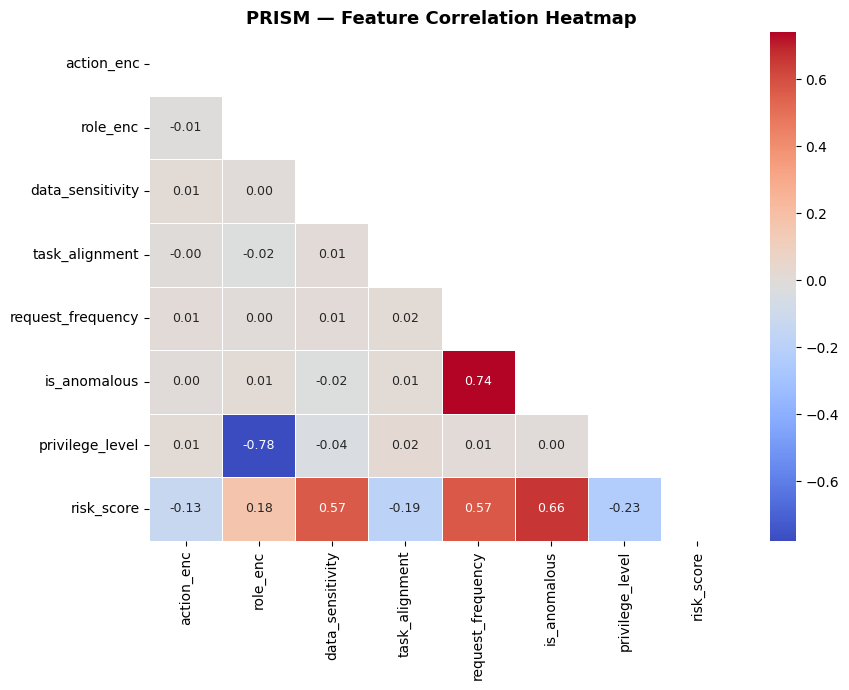

In [ ]:
le_action = LabelEncoder(); le_role = LabelEncoder()
df_corr = df.copy()
df_corr['action_enc'] = le_action.fit_transform(df_corr['action_type'])
df_corr['role_enc']   = le_role.fit_transform(df_corr['user_role'])
corr_cols = ['action_enc','role_enc','data_sensitivity','task_alignment','request_frequency','is_anomalous','privilege_level','risk_score']
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(df_corr[corr_cols].corr(), dtype=bool))
sns.heatmap(df_corr[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', mask=mask, ax=ax, linewidths=0.5, annot_kws={'size':9})
ax.set_title('PRISM — Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prism_plots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Train Models

In [ ]:
df_model = df.copy()
df_model['action_type'] = le_action.transform(df_model['action_type'])
df_model['user_role']   = le_role.transform(df_model['user_role'])
le_decision = LabelEncoder()
df_model['decision_enc'] = le_decision.fit_transform(df_model['decision'])
print('Decision mapping:', dict(zip(le_decision.classes_, le_decision.transform(le_decision.classes_))))

FEATURES = ['action_type','user_role','data_sensitivity','task_alignment','request_frequency','time_of_day','is_anomalous','privilege_level']
X = df_model[FEATURES]; y = df_model['decision_enc']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=SEED, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Decision mapping: {'allow': np.int64(0), 'deny': np.int64(1), 'escalate': np.int64(2)}
Train: 4000 | Test: 1000


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED),
    'XGBoost (PRISM)':     XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                          use_label_encoder=False, eval_metric='mlogloss', random_state=SEED),
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    results[name] = {'model':model,'y_pred':y_pred,
        'accuracy':accuracy_score(y_test,y_pred),'f1':f1_score(y_test,y_pred,average='macro'),
        'precision':precision_score(y_test,y_pred,average='macro'),'recall':recall_score(y_test,y_pred,average='macro'),
        'cv_mean':cv.mean(),'cv_std':cv.std()}
    print(f'{name:25s} Acc:{results[name]["accuracy"]:.4f} F1:{results[name]["f1"]:.4f} CV:{cv.mean():.4f}±{cv.std():.4f}')

Logistic Regression       Acc:0.8870 F1:0.7699 CV:0.8900±0.0050
Random Forest             Acc:0.9240 F1:0.8143 CV:0.9292±0.0044
XGBoost (PRISM)           Acc:0.9330 F1:0.8661 CV:0.9456±0.0063


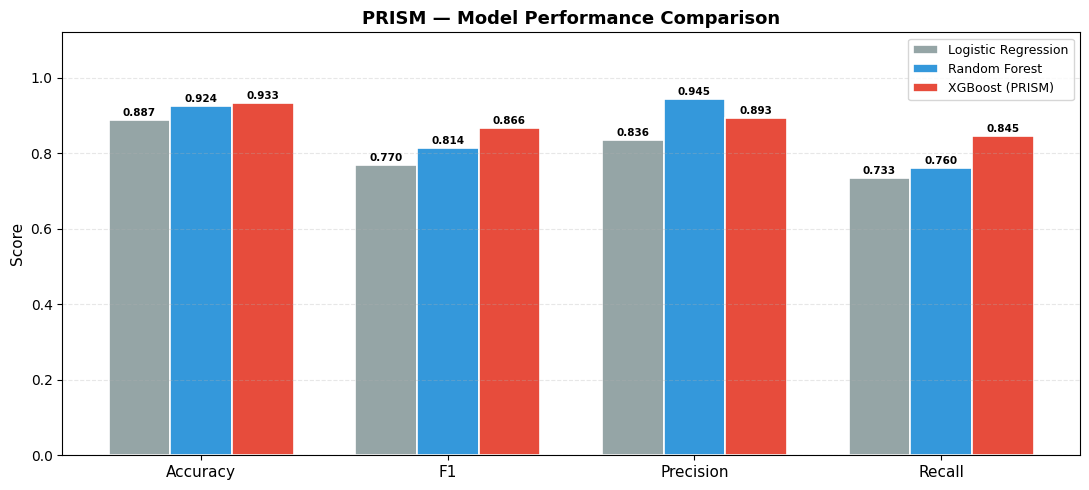

In [ ]:
metrics=['accuracy','f1','precision','recall']; m_labels=['Accuracy','F1','Precision','Recall']
model_names=list(results.keys()); x=np.arange(len(metrics)); width=0.25
bar_colors=['#95a5a6','#3498db','#e74c3c']
fig,ax=plt.subplots(figsize=(11,5))
for i,(name,color) in enumerate(zip(model_names,bar_colors)):
    vals=[results[name][m] for m in metrics]
    bars=ax.bar(x+i*width,vals,width,label=name,color=color,edgecolor='white',linewidth=1.2)
    for bar,val in zip(bars,vals): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,f'{val:.3f}',ha='center',va='bottom',fontsize=7.5,fontweight='bold')
ax.set_xticks(x+width); ax.set_xticklabels(m_labels,fontsize=11)
ax.set_ylim(0,1.12); ax.set_ylabel('Score',fontsize=11)
ax.set_title('PRISM — Model Performance Comparison',fontsize=13,fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.savefig('prism_plots/04_model_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

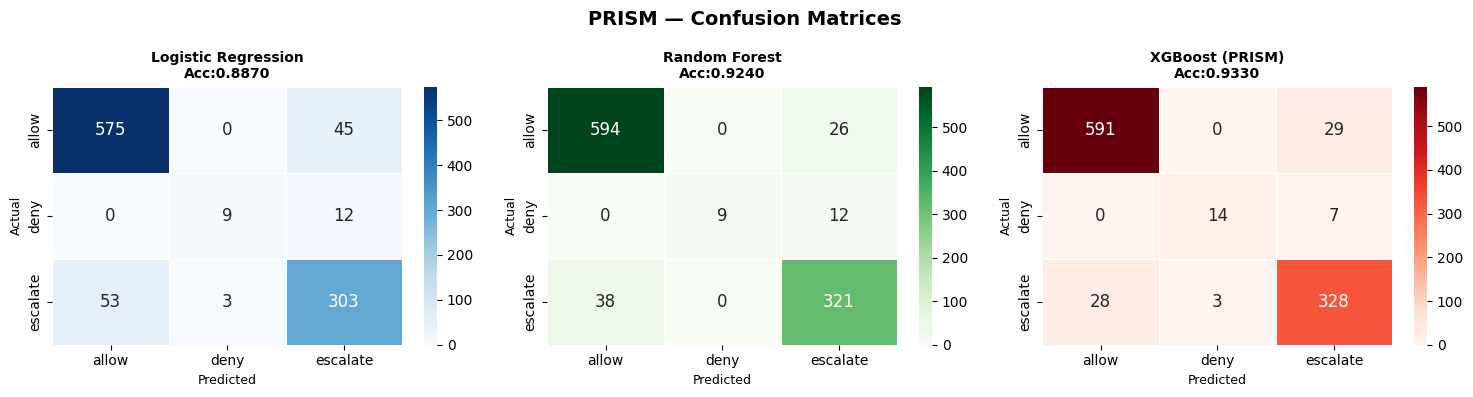

In [ ]:
class_names=le_decision.classes_
fig,axes=plt.subplots(1,3,figsize=(15,4))
fig.suptitle('PRISM — Confusion Matrices',fontsize=14,fontweight='bold')
for ax,(name,res),cmap in zip(axes,results.items(),['Blues','Greens','Reds']):
    cm=confusion_matrix(y_test,res['y_pred'])
    sns.heatmap(cm,annot=True,fmt='d',cmap=cmap,xticklabels=class_names,yticklabels=class_names,ax=ax,linewidths=0.5,annot_kws={'size':12})
    ax.set_title(f'{name}\nAcc:{res["accuracy"]:.4f}',fontsize=10,fontweight='bold')
    ax.set_xlabel('Predicted',fontsize=9); ax.set_ylabel('Actual',fontsize=9)
plt.tight_layout()
plt.savefig('prism_plots/05_confusion_matrices.png',dpi=150,bbox_inches='tight')
plt.show()

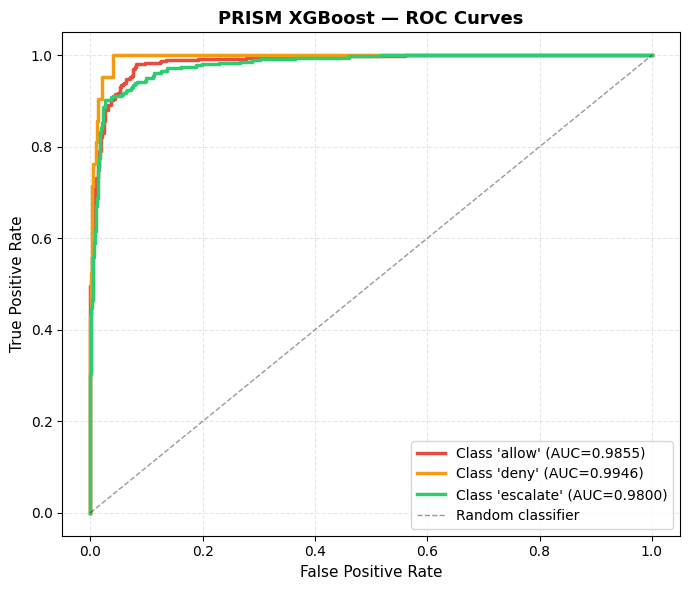

In [ ]:
xgb_model=results['XGBoost (PRISM)']['model']
y_prob=xgb_model.predict_proba(X_test)
fig,ax=plt.subplots(figsize=(7,6))
roc_colors=['#e74c3c','#f39c12','#2ecc71']
for i,(cls,color) in enumerate(zip(class_names,roc_colors)):
    y_bin=(y_test==i).astype(int)
    fpr,tpr,_=roc_curve(y_bin,y_prob[:,i])
    auc=roc_auc_score(y_bin,y_prob[:,i])
    ax.plot(fpr,tpr,color=color,linewidth=2.5,label=f"Class '{cls}' (AUC={auc:.4f})")
ax.plot([0,1],[0,1],'k--',alpha=0.4,linewidth=1,label='Random classifier')
ax.set_xlabel('False Positive Rate',fontsize=11); ax.set_ylabel('True Positive Rate',fontsize=11)
ax.set_title('PRISM XGBoost — ROC Curves',fontsize=13,fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3,linestyle='--')
plt.tight_layout()
plt.savefig('prism_plots/06_roc_curves.png',dpi=150,bbox_inches='tight')
plt.show()

## Step 4: SHAP Explainability

<Figure size 640x480 with 0 Axes>

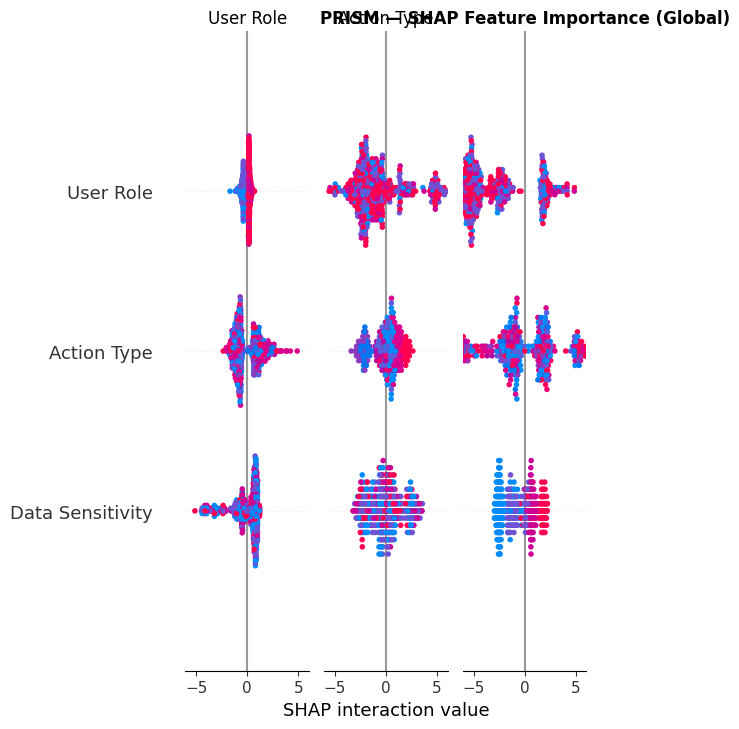

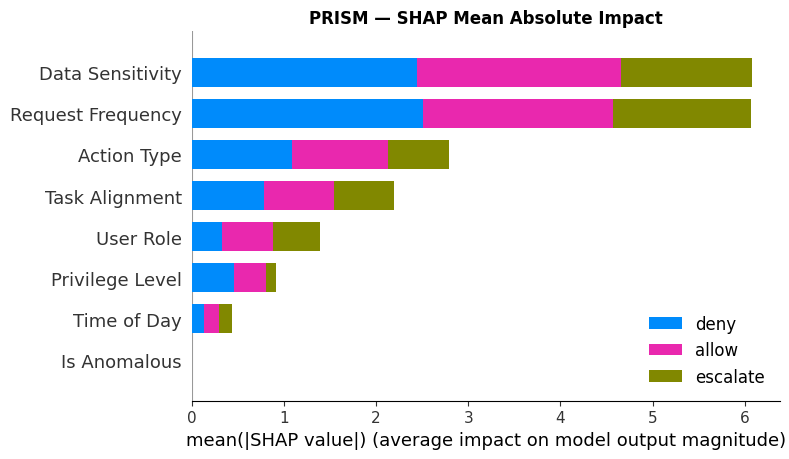

In [ ]:
explainer=shap.TreeExplainer(xgb_model)
shap_values=explainer.shap_values(X_test[:500])
feature_labels=['Action Type','User Role','Data Sensitivity','Task Alignment','Request Frequency','Time of Day','Is Anomalous','Privilege Level']
plt.figure()
shap.summary_plot(shap_values,X_test[:500],feature_names=feature_labels,class_names=class_names,show=False,max_display=8)
plt.title('PRISM — SHAP Feature Importance (Global)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('prism_plots/07_shap_summary.png',dpi=150,bbox_inches='tight')
plt.show()
plt.figure()
shap.summary_plot(shap_values,X_test[:500],feature_names=feature_labels,class_names=class_names,plot_type='bar',show=False,max_display=8)
plt.title('PRISM — SHAP Mean Absolute Impact',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('prism_plots/08_shap_bar.png',dpi=150,bbox_inches='tight')
plt.show()

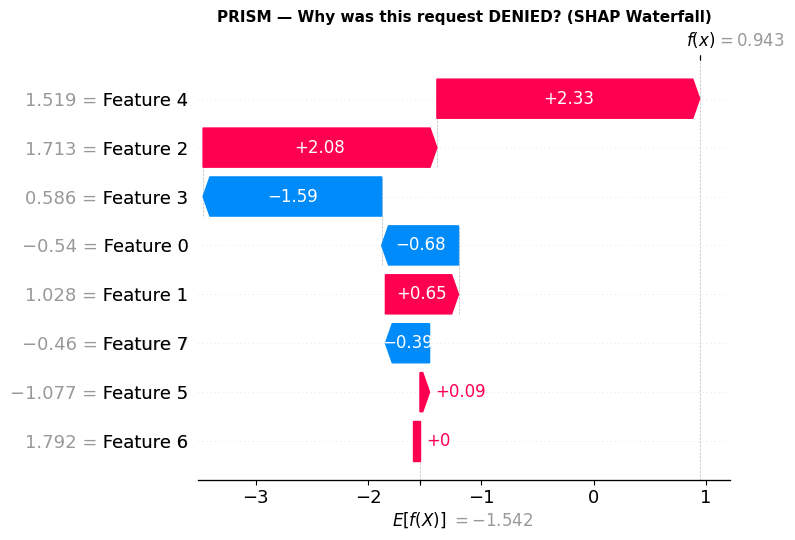

✅ Saved: 09_shap_waterfall.png


In [ ]:
deny_class_idx=list(le_decision.classes_).index('deny')
deny_indices=np.where(y_test==deny_class_idx)[0]
sample_idx=deny_indices[0]
shap_explain=shap.TreeExplainer(xgb_model)
sv=shap_explain(X_test[sample_idx:sample_idx+1])
plt.figure()
shap.plots.waterfall(sv[0,:,deny_class_idx],show=False,max_display=8)
plt.title('PRISM — Why was this request DENIED? (SHAP Waterfall)',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig('prism_plots/09_shap_waterfall.png',dpi=150,bbox_inches='tight')
plt.show()
print('✅ Saved: 09_shap_waterfall.png')

## Step 5: Anomaly Detection

In [ ]:
iso_forest=IsolationForest(contamination=0.08,random_state=SEED)
iso_forest.fit(X_train)
anomaly_preds=iso_forest.predict(X_test)
anomaly_count=(anomaly_preds==-1).sum()
print(f'IsolationForest: {anomaly_count} anomalies detected ({anomaly_count/len(X_test)*100:.1f}%)')

IsolationForest: 87 anomalies detected (8.7%)


## Step 6: Save All Artifacts

In [ ]:
print('\n' + '='*60)
print('  PRISM — XGBoost Full Classification Report')
print('='*60)
print(classification_report(y_test, results['XGBoost (PRISM)']['y_pred'], target_names=class_names))
print('\nCross-Validation Summary:')
for name,res in results.items():
    print(f'  {name:25s}: {res["cv_mean"]:.4f} ± {res["cv_std"]:.4f}')

joblib.dump(xgb_model,   'model.pkl')
joblib.dump(scaler,      'scaler.pkl')
joblib.dump(explainer,   'explainer.pkl')
joblib.dump(le_decision, 'label_encoder.pkl')
joblib.dump(le_action,   'action_encoder.pkl')
joblib.dump(le_role,     'role_encoder.pkl')
joblib.dump(iso_forest,  'anomaly_detector.pkl')
print('\n✅ All artifacts saved!')
print('📁 Download: prism_plots/ folder → paper figures')
print('📁 Download: *.pkl files → backend')


  PRISM — XGBoost Full Classification Report
              precision    recall  f1-score   support

       allow       0.95      0.95      0.95       620
        deny       0.82      0.67      0.74        21
    escalate       0.90      0.91      0.91       359

    accuracy                           0.93      1000
   macro avg       0.89      0.84      0.87      1000
weighted avg       0.93      0.93      0.93      1000


Cross-Validation Summary:
  Logistic Regression      : 0.8900 ± 0.0050
  Random Forest            : 0.9292 ± 0.0044
  XGBoost (PRISM)          : 0.9456 ± 0.0063

✅ All artifacts saved!
📁 Download: prism_plots/ folder → paper figures
📁 Download: *.pkl files → backend


## Step 7: Downloading CSV files

In [ ]:
from google.colab import files
import shutil, os

# ── Download all PKL files + CSV ──────────────────
artifacts = [
    'model.pkl',
    'scaler.pkl',
    'explainer.pkl',
    'label_encoder.pkl',
    'action_encoder.pkl',
    'role_encoder.pkl',
    'anomaly_detector.pkl',
    'prism_dataset.csv'
]
for f in artifacts:
    files.download(f)
    print(f'✅ Downloaded {f}')

# ── Zip and download prism_plots folder ───────────
shutil.make_archive('prism_plots', 'zip', 'prism_plots')
files.download('prism_plots.zip')
print('✅ Downloaded prism_plots.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded prism_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded prism_plots.zip
